## Setup and Installation

In [1]:
# Installing required packages
!pip install sentence-transformers numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached sentence_transformers-5.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached torch-2.10.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
Using cached sentence_transformers-5.3.0-py3-none-any.whl (512 kB)
Using cached transformers-5.3.0-py3-none-any.whl (10.7 MB)
Using cached huggingface_hu

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\VisheshPancholi\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\torch\\_inductor\\codegen\\cpp_micro_gemm.py'
Check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\VisheshPancholi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Importing required libraries
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

C:\Users\VisheshPancholi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## Step 1: Define 10 Sentences Across 3 Topics

Topics:
- **Cricket** (4 sentences)
- **Cooking** (3 sentences)
- **Cybersecurity** (3 sentences)

In [5]:
# Define sentences across three topics
sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent six over the boundary line.",
    "The spinner delivered a perfect googly that deceived the batsman completely.",
    "India won the cricket match by chasing down the target in the final over.",
    "The fielder took a spectacular diving catch at the boundary.",
    
    # Cooking (3 sentences)
    "Add fresh herbs and spices to enhance the flavor of your pasta sauce.",
    "Marinate the chicken overnight for tender and juicy results.",
    "Bake the cake at 180 degrees Celsius for exactly 30 minutes.",
    
    # Cybersecurity (3 sentences)
    "Always use strong passwords with a combination of letters, numbers, and symbols.",
    "Phishing attacks trick users into revealing sensitive information through fake emails.",
    "Implement multi-factor authentication to add an extra layer of security to your accounts."
]

# Display sentences with labels
topics = ['Cricket', 'Cricket', 'Cricket', 'Cricket', 
          'Cooking', 'Cooking', 'Cooking',
          'Cybersecurity', 'Cybersecurity', 'Cybersecurity']

print("\n=== 10 Sentences Across 3 Topics ===")
for i, (sentence, topic) in enumerate(zip(sentences, topics), 1):
    print(f"\n{i}. [{topic}]")
    print(f"   {sentence}")


=== 10 Sentences Across 3 Topics ===

1. [Cricket]
   The batsman hit a magnificent six over the boundary line.

2. [Cricket]
   The spinner delivered a perfect googly that deceived the batsman completely.

3. [Cricket]
   India won the cricket match by chasing down the target in the final over.

4. [Cricket]
   The fielder took a spectacular diving catch at the boundary.

5. [Cooking]
   Add fresh herbs and spices to enhance the flavor of your pasta sauce.

6. [Cooking]
   Marinate the chicken overnight for tender and juicy results.

7. [Cooking]
   Bake the cake at 180 degrees Celsius for exactly 30 minutes.

8. [Cybersecurity]
   Always use strong passwords with a combination of letters, numbers, and symbols.

9. [Cybersecurity]
   Phishing attacks trick users into revealing sensitive information through fake emails.

10. [Cybersecurity]
   Implement multi-factor authentication to add an extra layer of security to your accounts.


## Step 2: Generate Embeddings Using Sentence-Transformers

Using the `all-MiniLM-L6-v2` model to generate embeddings.

In [6]:
# Load the sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully!")

# Generate embeddings for all sentences
embeddings = model.encode(sentences)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Number of sentences: {len(sentences)}")
print(f"Embedding dimension: {embeddings.shape[1]}")

C:\Users\VisheshPancholi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\VisheshPancholi\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.war

Model loaded successfully!

Embeddings shape: (10, 384)
Number of sentences: 10
Embedding dimension: 384


## Step 3: Compute 10×10 Cosine Similarity Matrix

In [7]:
# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("\n=== Cosine Similarity Matrix (10×10) ===")
print("\nMatrix shape:", similarity_matrix.shape)
print("\nSimilarity Matrix:")
print(np.round(similarity_matrix, 3))


=== Cosine Similarity Matrix (10×10) ===

Matrix shape: (10, 10)

Similarity Matrix:
[[ 1.     0.428  0.428  0.382 -0.013  0.055  0.033 -0.059  0.003 -0.011]
 [ 0.428  1.     0.436  0.345 -0.033  0.05   0.112  0.011  0.185 -0.007]
 [ 0.428  0.436  1.     0.306 -0.024  0.037  0.021 -0.117  0.041 -0.071]
 [ 0.382  0.345  0.306  1.    -0.066 -0.001 -0.052 -0.057  0.004 -0.041]
 [-0.013 -0.033 -0.024 -0.066  1.     0.35   0.061  0.084  0.042  0.111]
 [ 0.055  0.05   0.037 -0.001  0.35   1.     0.145  0.069  0.013  0.008]
 [ 0.033  0.112  0.021 -0.052  0.061  0.145  1.     0.013  0.125  0.037]
 [-0.059  0.011 -0.117 -0.057  0.084  0.069  0.013  1.     0.281  0.613]
 [ 0.003  0.185  0.041  0.004  0.042  0.013  0.125  0.281  1.     0.379]
 [-0.011 -0.007 -0.071 -0.041  0.111  0.008  0.037  0.613  0.379  1.   ]]


## Step 4: Visualize Similarity Matrix as Heatmap

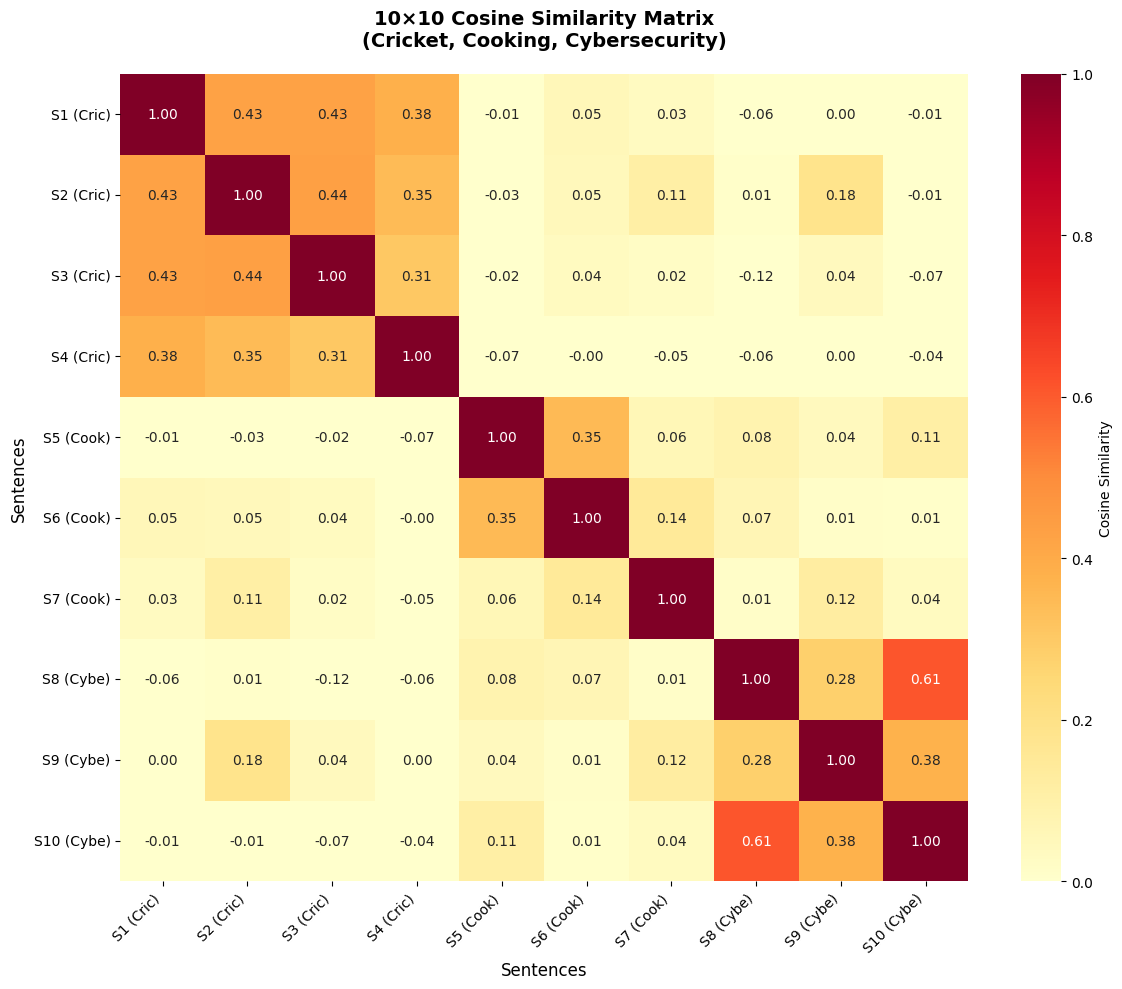


✓ Heatmap displayed successfully!


In [8]:
# Create heatmap visualization
plt.figure(figsize=(12, 10))

# Create labels for the heatmap
labels = [f"S{i+1} ({topics[i][:4]})" for i in range(len(sentences))]

# Plot heatmap
sns.heatmap(similarity_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='YlOrRd', 
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'label': 'Cosine Similarity'},
            vmin=0, 
            vmax=1)

plt.title('10×10 Cosine Similarity Matrix\n(Cricket, Cooking, Cybersecurity)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Sentences', fontsize=12)
plt.ylabel('Sentences', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Heatmap displayed successfully!")

## Step 5: Query Similarity - Find Top 2 Most Similar Sentences

Query: **"The bowler took three wickets in one over"**

In [9]:
# Define the query sentence
query = "The bowler took three wickets in one over"

print("\n=== Query Sentence ===")
print(f"Query: {query}")

# Generate embedding for the query
query_embedding = model.encode([query])

# Compute cosine similarity between query and all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

print("\n=== Similarity Scores for All Sentences ===")
for i, (sentence, topic, score) in enumerate(zip(sentences, topics, query_similarities), 1):
    print(f"\n{i}. [{topic}] (Score: {score:.4f})")
    print(f"   {sentence}")


=== Query Sentence ===
Query: The bowler took three wickets in one over

=== Similarity Scores for All Sentences ===

1. [Cricket] (Score: 0.5277)
   The batsman hit a magnificent six over the boundary line.

2. [Cricket] (Score: 0.4697)
   The spinner delivered a perfect googly that deceived the batsman completely.

3. [Cricket] (Score: 0.5510)
   India won the cricket match by chasing down the target in the final over.

4. [Cricket] (Score: 0.3045)
   The fielder took a spectacular diving catch at the boundary.

5. [Cooking] (Score: 0.0311)
   Add fresh herbs and spices to enhance the flavor of your pasta sauce.

6. [Cooking] (Score: 0.0221)
   Marinate the chicken overnight for tender and juicy results.

7. [Cooking] (Score: 0.0963)
   Bake the cake at 180 degrees Celsius for exactly 30 minutes.

8. [Cybersecurity] (Score: -0.0444)
   Always use strong passwords with a combination of letters, numbers, and symbols.

9. [Cybersecurity] (Score: 0.0008)
   Phishing attacks trick users 

In [10]:
# Find top 2 most similar sentences
top_2_indices = np.argsort(query_similarities)[-2:][::-1]

print("\n" + "="*70)
print("=== TOP 2 MOST SIMILAR SENTENCES ===")
print("="*70)

for rank, idx in enumerate(top_2_indices, 1):
    print(f"\nRank {rank}:")
    print(f"  Topic: {topics[idx]}")
    print(f"  Sentence: {sentences[idx]}")
    print(f"  Similarity Score: {query_similarities[idx]:.4f}")

print("\n" + "="*70)


=== TOP 2 MOST SIMILAR SENTENCES ===

Rank 1:
  Topic: Cricket
  Sentence: India won the cricket match by chasing down the target in the final over.
  Similarity Score: 0.5510

Rank 2:
  Topic: Cricket
  Sentence: The batsman hit a magnificent six over the boundary line.
  Similarity Score: 0.5277

